In [2]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [3]:
import sys

sys.path.append('../scripts')

In [4]:
import numpy as np
import scanpy as sc
import os
import matplotlib.pyplot as plt
import decoupler as dc
import scipy.sparse as sp
import pandas as pd

from scipy.stats import pearsonr, spearmanr

from cellina import make_neighbor_perturbation
from cellina_graph import make_perturbed_expression
from utils import set_seed
from train_loo import preprocess_crc, preprocess_merfish, _load_model, split_indices
from counterfactual_analysis import compute_rmse, compute_edistance, mixing_index, get_lfc, precision, direction_match, compute_mse_lfc, _to_dense
from counterfactual_analysis import get_perturbation_logfc, get_global_perturbation_logfc
from configs.adata_crc_config import ADATA_ARGS as ADATA_ARGS_CRC
from configs.adata_merfish_config import ADATA_ARGS as ADATA_ARGS_MERFISH

/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import cellina
import cellina_graph

cellina.__version__, cellina_graph.__version__

('0.7.3', '0.0.9')

In [6]:
set_seed(0)

In [7]:
DATASET_NAME = "crc"  # or "merfish"
MODEL_ROOT = "/data2/a330d/data/ood/trained"

In [8]:
CRC_PATHS = [
    #"/data2/a330d/datasets/crc/raw_zenodo/crc_210.h5ad",
    #"/data2/a330d/datasets/crc/raw_zenodo/crc_221.h5ad",
    "/data2/a330d/datasets/crc/raw_zenodo/crc_231.h5ad",
    "/data2/a330d/datasets/crc/raw_zenodo/crc_232.h5ad",
    "/data2/a330d/datasets/crc/raw_zenodo/crc_242.h5ad",
    #"/data2/a330d/datasets/crc/raw_zenodo/crc_120.h5ad",
]

CRC_HOLDOUTS = [
    "Endothelial",
    "Epithelial",
    "Fibroblast",
    "Myeloid",
    "T_cell",
]

MERFISH_PATHS = [
    "/data/a330d/datasets/MERFISH_mouse_brain/C57BL6J-2.036.h5ad",    
    "/data/a330d/datasets/MERFISH_mouse_brain/C57BL6J-2.039.h5ad",
    "/data/a330d/datasets/MERFISH_mouse_brain/C57BL6J-2.041.h5ad",
]

MERFISH_HOLDOUTS = [
    'glutamatergic neuron',
    'oligodendrocyte',
    'astrocyte',
    'GABAergic neuron',
    'endothelial cell',
]

PATHS = CRC_PATHS if DATASET_NAME == "crc" else MERFISH_PATHS
HOLDOUT_CELLTYPES = CRC_HOLDOUTS if DATASET_NAME == "crc" else MERFISH_HOLDOUTS
DATA_ARGS = ADATA_ARGS_CRC if DATASET_NAME == "crc" else ADATA_ARGS_MERFISH
COUNTS_PER_K = 1e4

In [9]:
n_top_genes = DATA_ARGS.get('n_top_genes')
labels_key = DATA_ARGS.get('labels_key')
domains_key = DATA_ARGS.get('domains_key')
batch_key = DATA_ARGS.get('batch_key')
control_domain = DATA_ARGS.get('control_domains')[0]
holdout_domains = DATA_ARGS.get('holdout_domains')
n_neighbors = DATA_ARGS.get('n_neighbors')
batch_size = 1024
library_size = 'latent'
n_deg = 50
save_name =  "cellina-random-n"

In [12]:
# Create SLIDES which contain file names from PATHS - first split by "/" and take last part, then split by "." and take first part
SLIDES = [path.split("/")[-1].split(".h5ad")[0] for path in PATHS]

In [13]:
results = []
for path, slide_id in zip(PATHS, SLIDES):
    model_class = 'cellina' if save_name == "cellina-random-n" else 'cellina_graph'
    model_name = 'cellina' if model_class == 'cellina' else 'cellina-graph'
    adata = sc.read(path)
    
    if DATASET_NAME == 'crc':
        adata = preprocess_crc(adata, n_top_genes=n_top_genes, n_neighbors=n_neighbors, labels_key=labels_key, domains_key=domains_key)
    elif DATASET_NAME == 'merfish':
        adata = preprocess_merfish(adata, n_top_genes=n_top_genes, n_neighbors=n_neighbors, labels_key=labels_key, domains_key=domains_key)
    else:
        raise ValueError(f"Unknown dataset_name: {DATASET_NAME}. Supported: crc, merfish")
    
    for holdout_celltype in HOLDOUT_CELLTYPES:
        # 50 times * in print
        print(f"{'='*50} Slide: {slide_id}, Holdout Celltype: {holdout_celltype} {'='*50}")
        # create splits
        train_idx, val_idx, test_idx = split_indices(adata,
                                                    holdout_celltype,
                                                    labels_key=labels_key,
                                                    domains_key=domains_key,
                                                    holdout_domains=holdout_domains,
                                                    seed=0)

        splits = (train_idx, val_idx, test_idx)

        save_dir = os.path.join(MODEL_ROOT, slide_id, holdout_celltype, model_name)
        
        try:
            model = _load_model(save_dir,
                                model_class=model_class,
                                adata=adata,
                                splits=splits)
        except Exception as e:
            print(f"Failed to load model from {save_dir} with error: {e}")
            continue
        is_control_region = adata.obs[domains_key]==(control_domain)
        is_holdout_ct = adata.obs[labels_key].astype(str) == holdout_celltype
        mask_control = is_control_region & is_holdout_ct
        idx_control = np.where(mask_control.values)[0]    
        
        for hd in holdout_domains:
                is_holdout_region = adata.obs[domains_key].astype(str) == hd
                mask_ct_target = is_holdout_ct & is_holdout_region
                mask_global_target = is_holdout_region
                idx_target = np.where(mask_global_target.values)[0]
                
                args_gex = {
                    "indices": idx_control,
                    "batch_size": batch_size,
                    "seed": 0,
                }
                if model_class.lower() == 'cellina_graph':
                    args_gex["n_neighbors_per_seed"] = 50
                    # "neighbour_indices" are indices of the neighbors of idx_target cells
                    conn = adata.obsp["spatial_connectivities"]
                    sub_conn = conn[idx_target]                # rows for target cells
                    neighbor_indices = sub_conn.nonzero()[1]   # all neighbors at once
                    neighbor_indices = np.unique(neighbor_indices)
                    args_gex["neighbour_indices"] = neighbor_indices
                else:
                    args_gex["adata"] = adata
                    args_gex["neighbour_indices"] = idx_target
                
                cf_counts = model.get_counterfactual_expression(**args_gex)
                
                # Compute stats
                control = adata.layers['counts'][mask_control.values, :]
                target = adata.layers['counts'][mask_ct_target.values, :]
                control, target = _to_dense(control), _to_dense(target)
                counterfactual = cf_counts

                gt_lfc, cf_lfc, deg = get_lfc(control=control, target=target, counterfactual=counterfactual, n_deg=n_deg)

                spear, _ = spearmanr(gt_lfc[deg], cf_lfc[deg])
                pear, _ = pearsonr(gt_lfc[deg], cf_lfc[deg])
                prec = precision(gt_lfc, cf_lfc, k=n_deg, use_abs=True)
                dir_match = direction_match(gt_lfc, cf_lfc, k=n_deg, normalize="intersection")
                dir_match_k = direction_match(gt_lfc, cf_lfc, k=n_deg, normalize="k")
                dir_match_gt = direction_match(gt_lfc, cf_lfc, k=n_deg, normalize="gt_topk")
                mix_idx = mixing_index(observed=target, predicted=counterfactual, library_size=COUNTS_PER_K)
                edist_global = compute_edistance(adata, observed=target, predicted=counterfactual, deg=None, library_size=COUNTS_PER_K)
                edist_local = compute_edistance(adata, observed=target, predicted=counterfactual, deg=None, library_size=COUNTS_PER_K, local=True)
                edist_pca_log = compute_edistance(adata, observed=target, predicted=counterfactual, deg=None, library_size=COUNTS_PER_K, local=True, use_pca=True)
                edist_pca = compute_edistance(adata, observed=target, predicted=counterfactual, deg=None, library_size=COUNTS_PER_K, local=True, use_pca=True, log1p=False)
                rmse = compute_rmse(observed=target, predicted=counterfactual, deg=deg, library_size=COUNTS_PER_K)
                mse_lfc = compute_mse_lfc(gt_vec=gt_lfc, cf_vec=cf_lfc, deg=deg)

                results.append(
                        dict(
                        dataset_name=DATASET_NAME,
                        sid=slide_id,
                        control_domain=control_domain,
                        target_domain=hd,
                        n_deg=n_deg,
                        model_name=save_name,
                        holdout_celltype=holdout_celltype,
                        spearman=spear,
                        pearson=pear,
                        precision=prec,
                        direction_match=dir_match,
                        direction_match_k=dir_match_k,
                        direction_match_gt=dir_match_gt,
                        mixing_index=mix_idx,
                        edistance_global=edist_global,
                        edistance_local=edist_local,
                        edistance_pca_log=edist_pca_log,
                        edistance_pca=edist_pca,
                        rmse=rmse,
                        mse_lfc=mse_lfc,
                        )
                )

/data/a330d/projects/cellina-reproducibility-worktrees/major-loo/notebooks/../scripts/train_loo.py:175: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[labels_key] = adata.obs[labels_key].astype("category")
INFO: Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
2026-05-05 14:02:35 | [INFO] Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


================================================== Slide: crc_231, Holdout Celltype: Endothelial ==================================================
INFO     File /data2/a330d/data/ood/trained/crc_231/Endothelial/cellina/model.pt already downloaded                


/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        
cellina loaded model from /data2/a330d/data/ood/trained/crc_231/Endothelial/cellina
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
INFO: Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
2026-05-05 14:03:04 | [INFO] Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


...

INFO: Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
2026-05-05 14:13:14 | [INFO] Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/ood/trained/crc_242/T_cell/cellina/model.pt already downloaded                     


/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        
cellina loaded model from /data2/a330d/data/ood/trained/crc_242/T_cell/cellina
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


In [117]:
results_csv_name = f'../results/loo_cellina_{DATASET_NAME}_DEG_{n_deg}_random_neighbors.csv'
df_results = pd.DataFrame(results)
df_results.to_csv(f"{results_csv_name}", index=False)

In [118]:
# Load existing results
old = pd.read_csv(f'../results/loo_summary_{DATASET_NAME}_DEG_{n_deg}.csv')
old = old[old['model_name'].isin([model_name]) & (old['sid'].isin(SLIDES))]
old['rmse'] = old['rmse'].apply(lambda x: np.log10(x) if x > 0 else 0)


In [119]:
# Apply log10 to rmse, sqrt to mse_lfc
df_results['rmse'] = df_results['rmse'].apply(lambda x: np.log10(x) if x > 0 else 0)
df_results['mse_lfc'] = df_results['mse_lfc'].apply(lambda x: np.sqrt(x) if x > 0 else 0)

In [120]:
# Compare old and new metrics means for pearson, spearman, direction_match_k, edistance_pca_log, rmse, mse_lfc
metrics = ['pearson', 'spearman', 'direction_match_k', 'edistance_pca_log', 'rmse', 'mse_lfc']
comparison = {}
for metric in metrics:
    old_mean = round(old[metric].mean(), 2)
    new_mean = round(df_results[metric].mean(), 2)
    print(f"{metric}: ct_neighbors={old_mean}, random_neighbors={new_mean}, difference={new_mean - old_mean:.2f}")
    comparison[metric] = {
        'ct_neighbors': old_mean,
        'random_neighbors': new_mean,
        'difference': new_mean - old_mean
    }

pearson: ct_neighbors=0.8, random_neighbors=0.79, difference=-0.01
spearman: ct_neighbors=0.73, random_neighbors=0.73, difference=0.00
direction_match_k: ct_neighbors=0.3, random_neighbors=0.28, difference=-0.02
edistance_pca_log: ct_neighbors=6.97, random_neighbors=7.11, difference=0.14
rmse: ct_neighbors=4.2, random_neighbors=4.2, difference=0.00
mse_lfc: ct_neighbors=2.25, random_neighbors=1.4, difference=-0.85


In [121]:
df = pd.DataFrame(comparison).T

pretty_names = {
    "pearson": r"Pearson $r$ ↑",
    "spearman": r"Spearman $\rho$ ↑",
    "direction_match_k": r"Signed Precision ↑",
    "edistance_pca_log": r"E-distance ↓",
    "rmse": r"$\mathrm{RMSE}_{\mathrm{counts}}$ ↓",
    "mse_lfc": r"$\mathrm{RMSE}_{\mathrm{LFC}}$ ↓"
}
df = df.rename(index=pretty_names)


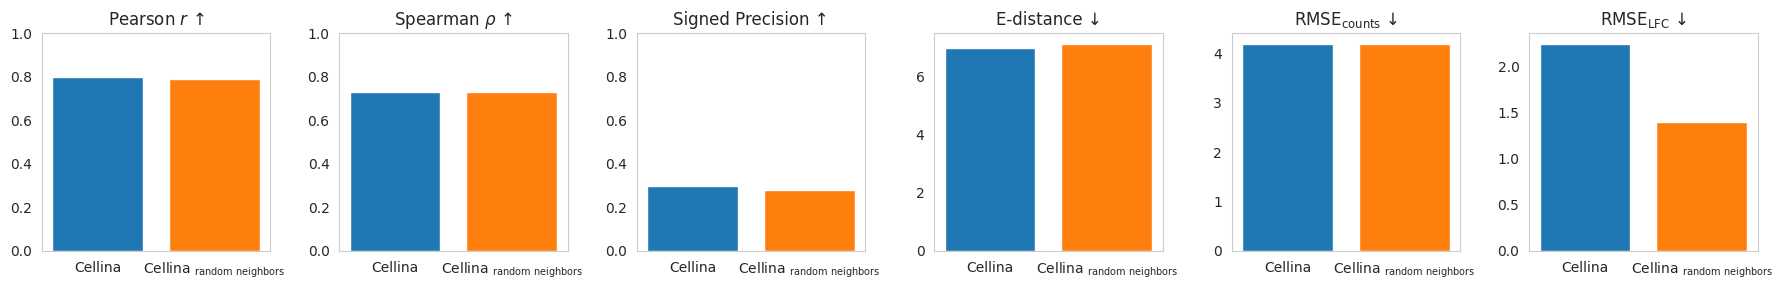

In [122]:
fig, axes = plt.subplots(1, len(metrics), figsize=(3 * len(metrics), 3))
axes = np.array(axes)  # ensures indexing works even for 1 subplot case

bounded_metrics = {r"Pearson $r$ ↑", r"Spearman $\rho$ ↑", r"Signed Precision ↑"}
labels = ["ct_neighbors", "random_neighbors"]
pretty_labels = {
    "ct_neighbors": r"Cellina",
    "random_neighbors": r'Cellina $_{\text{random neighbors}}$'
}
colors = {
    "Cellina": "#1f77b4",
    r'Cellina $_{\text{random neighbors}}$': "#ff7f0e"
}
metrics = df.index.tolist()
for i, metric in enumerate(metrics):
    ax = axes[i]
    vals = df.loc[metric, labels]

    x = np.array([0, .9])   # tighter spacing
    bar_width = 0.7        # slimmer bars

    ax.bar(
        x,
        vals,
        width=bar_width,
        color=[colors[pretty_labels[l]] for l in labels]
    )

    ax.set_xticks(x)
    ax.set_xticklabels([pretty_labels[l] for l in labels])

    ax.set_title(metric)
    ax.grid(False)
    
    if metric in bounded_metrics:
        ax.set_ylim(0, 1)

# optional cleanup
plt.tight_layout()
plt.show()

## Better Looking

In [ ]:
DATASET_NAME = "crc"
n_deg = 50

old = pd.read_csv(f'../results/loo_summary_{DATASET_NAME}_DEG_{n_deg}.csv')
new = pd.read_csv(f'../results/loo_cellina_{DATASET_NAME}_DEG_{n_deg}_random_neighbors.csv')

slides = new['sid'].unique().tolist()
old = old[(old['model_name'] == 'cellina') & (old['sid'].isin(slides))].copy()

old['rmse']    = old['rmse'].apply(lambda x: np.log10(x) if x > 0 else 0)
new['rmse']    = new['rmse'].apply(lambda x: np.log10(x) if x > 0 else 0)
new['mse_lfc'] = new['mse_lfc'].apply(lambda x: np.sqrt(x) if x > 0 else 0)
old['mse_lfc'] = old['mse_lfc'].apply(lambda x: np.sqrt(x) if x > 0 else 0)

In [ ]:
metrics = ['pearson', 'spearman', 'direction_match_k', 'edistance_pca_log', 'rmse', 'mse_lfc']

pretty_names = {
    'pearson':           r'Pearson $r$ $\uparrow$',
    'spearman':          r'Spearman $\rho$ $\uparrow$',
    'direction_match_k': r'Signed Precision $\uparrow$',
    'edistance_pca_log': r'E-distance $\downarrow$',
    'rmse':              r'$\mathrm{RMSE}_{\mathrm{counts}}$ $\downarrow$',
    'mse_lfc':           r'$\mathrm{RMSE}_{\mathrm{LFC}}$ $\downarrow$',
}

ct_means   = {m: old[m].mean() for m in metrics}
rand_means = {m: new[m].mean() for m in metrics}

ct_se   = {m: old[m].sem() for m in metrics}
rand_se = {m: new[m].sem() for m in metrics}

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the foll

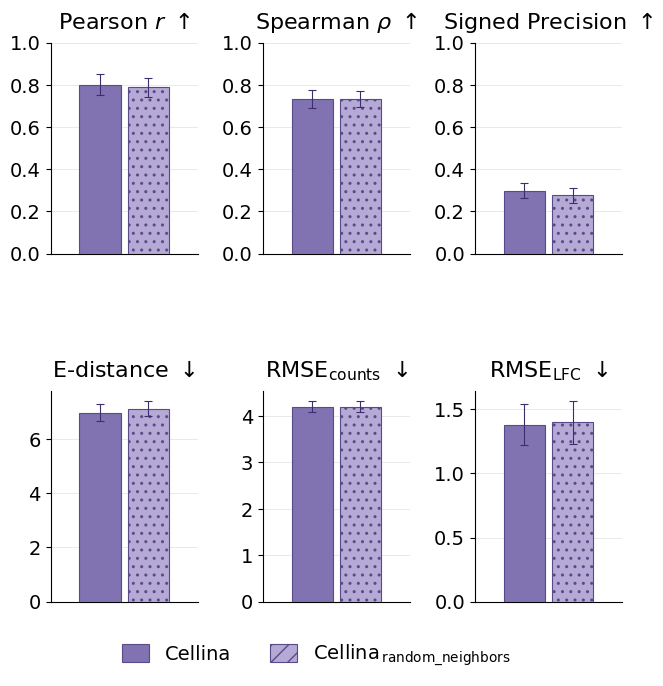

In [ ]:
import matplotlib as mpl
import matplotlib.patches as mpatches
import math

mpl.rcParams.update({
    'font.family':       'sans-serif',
    'font.sans-serif':   ['Helvetica', 'Arial'],
    'font.size':         16,
    'axes.titlesize':    16,
    'axes.labelsize':    14,
    'xtick.labelsize':   14,
    'ytick.labelsize':   14,
    'legend.fontsize':   14,
    'axes.linewidth':    0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'svg.fonttype':      'none',
})

COLOR_CT   = '#8172B2'
COLOR_RAND = '#B5A9D6'
EDGE_COLOR = '#5B4A8A'

bounded_metrics = {'pearson', 'spearman', 'direction_match_k'}

bar_width = 0.35
gap       = 0.06
x_ct      = -(bar_width / 2 + gap / 2)
x_rand    =  (bar_width / 2 + gap / 2)
margin    = bar_width * 0.7

n_metrics = len(metrics)
ncols     = math.ceil(n_metrics / 2)
nrows     = 2

fig, axes = plt.subplots(nrows, ncols, figsize=(2.2 * ncols, 7.0))

# Flatten and hide any unused axes (if n_metrics is odd)
axes_flat = axes.flatten()
for j in range(n_metrics, len(axes_flat)):
    axes_flat[j].set_visible(False)

for i, metric in enumerate(metrics):
    ax    = axes_flat[i]
    label = pretty_names[metric]
    v_ct   = ct_means[metric];   e_ct   = ct_se[metric]
    v_rand = rand_means[metric]; e_rand = rand_se[metric]

    err_kw = dict(lw=0.8, capsize=3, capthick=0.8)

    ax.bar(x_ct, v_ct, width=bar_width,
           color=COLOR_CT, edgecolor=EDGE_COLOR, linewidth=0.8,
           yerr=e_ct, error_kw=dict(ecolor='#3D2D6E', **err_kw), zorder=3)

    ax.bar(x_rand, v_rand, width=bar_width,
           color=COLOR_RAND, edgecolor=EDGE_COLOR, linewidth=0.8,
           hatch='..', yerr=e_rand,
           error_kw=dict(ecolor='#3D2D6E', **err_kw), zorder=3)

    ax.set_xlim(x_ct - bar_width / 2 - margin,
                x_rand + bar_width / 2 + margin)
    ax.set_xticks([])
    ax.set_title(label, pad=10)
    ax.grid(axis='y', linewidth=0.4, alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

    if metric in bounded_metrics:
        ax.set_ylim(0, 1)

# ── Legend ────────────────────────────────────────────────────────────────────
patch_ct   = mpatches.Patch(facecolor=COLOR_CT,   edgecolor=EDGE_COLOR,
                            linewidth=0.8, label='Cellina')
patch_rand = mpatches.Patch(facecolor=COLOR_RAND, edgecolor=EDGE_COLOR,
                            linewidth=0.8, hatch='//',
                            label=r'Cellina$_{\,\mathrm{random\_neighbors}}$')

fig.legend(handles=[patch_ct, patch_rand],
           ncol=2, loc='lower center',
           bbox_to_anchor=(0.5, 0.0),
           frameon=False, handlelength=1.4, handleheight=1.0)

plt.tight_layout()
plt.subplots_adjust(bottom=0.12, hspace=0.65)
plt.savefig('../figures/random_neighbors_loo.svg',
            format='svg', bbox_inches='tight', dpi=300)
plt.show()